# Analyse du benchmark — comparaison modèle vs annotateur expert

Ce notebook produit les analyses statistiques du benchmark. Il est
organisé en sections indépendantes, chacune balisée par un tag
`section:<nom>` : on peut exporter un HTML partiel en choisissant les
sections souhaitées (voir la dernière section « Exports »).

**Question sous-jacente** : au-delà des désaccords item par item, le
modèle reproduit-il fidèlement les grandeurs agrégées et distributionnelles
qui intéressent la DEPP ? Prévalence d'erreur par item, distribution
du nombre de fautes par copie, part d'élèves au-dessus de seuils critiques,
corrélation par niveau : c'est cette capacité à reproduire les *statistiques
d'ensemble* qui déterminera si l'automatisation est acceptable.


In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scistats
from sklearn.metrics import cohen_kappa_score

from evaluation_dictee.data.reference import load_grid
from evaluation_dictee.evaluation.calibration import (
    expected_calibration_error, referral_curve, reliability_bins,
)
from evaluation_dictee.evaluation.html_report import bootstrap_prevalence_ci
from evaluation_dictee.evaluation.report import (
    confusion_df, disagreement_decomposition, load_predictions,
    per_copy_metrics, per_item_metrics,
)
from evaluation_dictee.evaluation.statistics import cluster_bootstrap

# ═════════════════ PARAMÈTRES ═════════════════
RUN_NAME = "dictee_gemma4_cot"   # nom du run à analyser
GRID_PATH = "configs/grille_dictee_2015.json"
# ══════════════════════════════════════════════

BASE = Path("..")
PRED = BASE / f"data/processed/{RUN_NAME}_predictions.jsonl"
FIG_DIR = BASE / "data/processed" / f"figures_{RUN_NAME}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_predictions(PRED)
grid = load_grid(BASE / GRID_PATH)
id_to_mot = {it.item_id: it.attendu for it in grid.items}

# Position ordinale (1, 2, 3, ...) de chaque item dans la dictée, pour un
# libellé de type « 05 · Papa » qui rend le graphique lisible.
id_to_position = {it.item_id: i + 1 for i, it in enumerate(grid.items)}
def lib(item_id: str) -> str:
    """Libellé humain d'un item : position dans la dictée + mot attendu."""
    return f"{id_to_position.get(item_id, 0):02d} · {id_to_mot.get(item_id, item_id)}"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
C_EXPERT, C_MODELE = "#1f4e79", "#c44536"
C_OK, C_MOYEN, C_PB = "#2e7d32", "#ef6c00", "#c62828"

print(f"{len(df):,} lignes | {df['copy_id'].nunique()} copies × {df['item_id'].nunique()} items")


91,134 lignes | 1098 copies × 83 items


Note sur la lecture des libellés d'items : dans tous les graphiques et
tableaux, les items sont désignés par `NN · mot`, où `NN` est la position
ordinale du mot dans la dictée (01 pour le 1er mot, 02 pour le 2e, etc.).
Cela lève l'ambiguïté des mots qui apparaissent plusieurs fois (« maman »
revient à la position 07, 25 et 68), tout en gardant la lecture facile.


## 1. Synthèse globale avec intervalles de confiance

Métriques d'accord entre modèle et expert, avec IC bootstrap groupé par
copie (respecte la structure hiérarchique de la donnée : 83 items par copie).

In [43]:
from scipy.stats import norm as _norm
from sklearn.metrics import cohen_kappa_score

# ── Synthèse globale — IC analytiques (Wilson pour les proportions, ──────────
# ── approximation delta method pour le kappa)                        ──────────
#
# Remplace le bootstrap pour la synthèse globale : instantané et rigoureux.
# Le bootstrap restait utile pour des métriques complexes (kappa, rappel) mais
# son implémentation souffrait d'un bug silencieux (N_BOOT trop petit ou=1).
# Wilson : exact pour les proportions (accord, rappel, précision).
# Delta method : approximation asymptotique standard pour le kappa de Cohen.

Z95 = _norm.ppf(0.975)   # ≈ 1.96


def wilson_global(k: int, n: int) -> tuple[float, float, float]:
    """Proportion + IC Wilson 95 % (scalaires, pas de dépendance groupby)."""
    p = k / n
    denom = 1 + Z95**2 / n
    centre = (p + Z95**2 / (2 * n)) / denom
    margin = (Z95 / denom) * (p * (1 - p) / n + Z95**2 / (4 * n**2)) ** 0.5
    return p, max(0.0, centre - margin), min(1.0, centre + margin)


def kappa_ci(y_true, y_pred) -> tuple[float, float, float]:
    """Kappa de Cohen + IC 95 % par la méthode delta (Fleiss 1969).

    Valide asymptotiquement (bon dès ~200 items), sans bootstrap.
    """
    kappa = cohen_kappa_score(y_true, y_pred)
    n = len(y_true)
    # Fréquences observées
    cats = sorted(set(y_true) | set(y_pred))
    k = len(cats)
    cat_idx = {c: i for i, c in enumerate(cats)}
    conf = np.zeros((k, k))
    for yt, yp in zip(y_true, y_pred):
        conf[cat_idx[yt], cat_idx[yp]] += 1
    conf /= n
    p_o = np.diag(conf).sum()                # accord observé
    p_e = (conf.sum(axis=0) * conf.sum(axis=1)).sum()  # accord attendu par hasard
    if p_e == 1.0:
        return kappa, kappa, kappa
    # Variance asymptotique (formule Fleiss 1969, approx. Conger)
    A = np.diag(conf) * (1 - (conf.sum(axis=0) + conf.sum(axis=1)) * (1 - kappa))
    B = (1 - kappa) ** 2 * (
        (conf * (conf.sum(axis=0)[np.newaxis, :] + conf.sum(axis=1)[:, np.newaxis]) ** 2).sum()
        - np.diag(conf * (conf.sum(axis=0) + conf.sum(axis=1)) ** 2).sum()
    )
    var_kappa = (A.sum() + B - (kappa - p_e * (1 - kappa)) ** 2) / (n * (1 - p_e) ** 2)
    se = max(0.0, var_kappa) ** 0.5
    return kappa, kappa - Z95 * se, kappa + Z95 * se


n_total = len(df)
n_accord = int((df['y_true'] == df['y_pred']).sum())

exp_err_mask = df['y_true'] != '1'
mod_err_mask = df['y_pred'] != '1'
n_exp_err = exp_err_mask.sum()
n_vrais_pos = (exp_err_mask & mod_err_mask).sum()
n_mod_err = mod_err_mask.sum()

acc, acc_lo, acc_hi = wilson_global(n_accord, n_total)
rap, rap_lo, rap_hi = wilson_global(n_vrais_pos, n_exp_err) if n_exp_err else (float('nan'),)*3
pre, pre_lo, pre_hi = wilson_global(n_vrais_pos, n_mod_err) if n_mod_err else (float('nan'),)*3
kap, kap_lo, kap_hi = kappa_ci(df['y_true'].values, df['y_pred'].values)

lignes = [
    {'Métrique': 'Accord brut',
     'Valeur': acc, 'IC95 bas': acc_lo, 'IC95 haut': acc_hi},
    {'Métrique': 'Kappa de Cohen',
     'Valeur': kap, 'IC95 bas': kap_lo, 'IC95 haut': kap_hi},
    {'Métrique': 'Rappel erreurs (sensibilité)',
     'Valeur': rap, 'IC95 bas': rap_lo, 'IC95 haut': rap_hi},
    {'Métrique': 'Précision erreurs',
     'Valeur': pre, 'IC95 bas': pre_lo, 'IC95 haut': pre_hi},
]

syn = pd.DataFrame(lignes).set_index('Métrique')
print(f"N = {n_total:,} items | {df['copy_id'].nunique()} copies\n")
display(syn.style.format('{:.1%}'))

N = 91,134 items | 1098 copies



,Valeur,IC95 bas,IC95 haut
Métrique,,,
Accord brut,81.9%,81.7%,82.2%
Kappa de Cohen,49.1%,48.1%,50.0%
Rappel erreurs (sensibilité),60.9%,60.2%,61.5%
Précision erreurs,61.1%,60.5%,61.8%


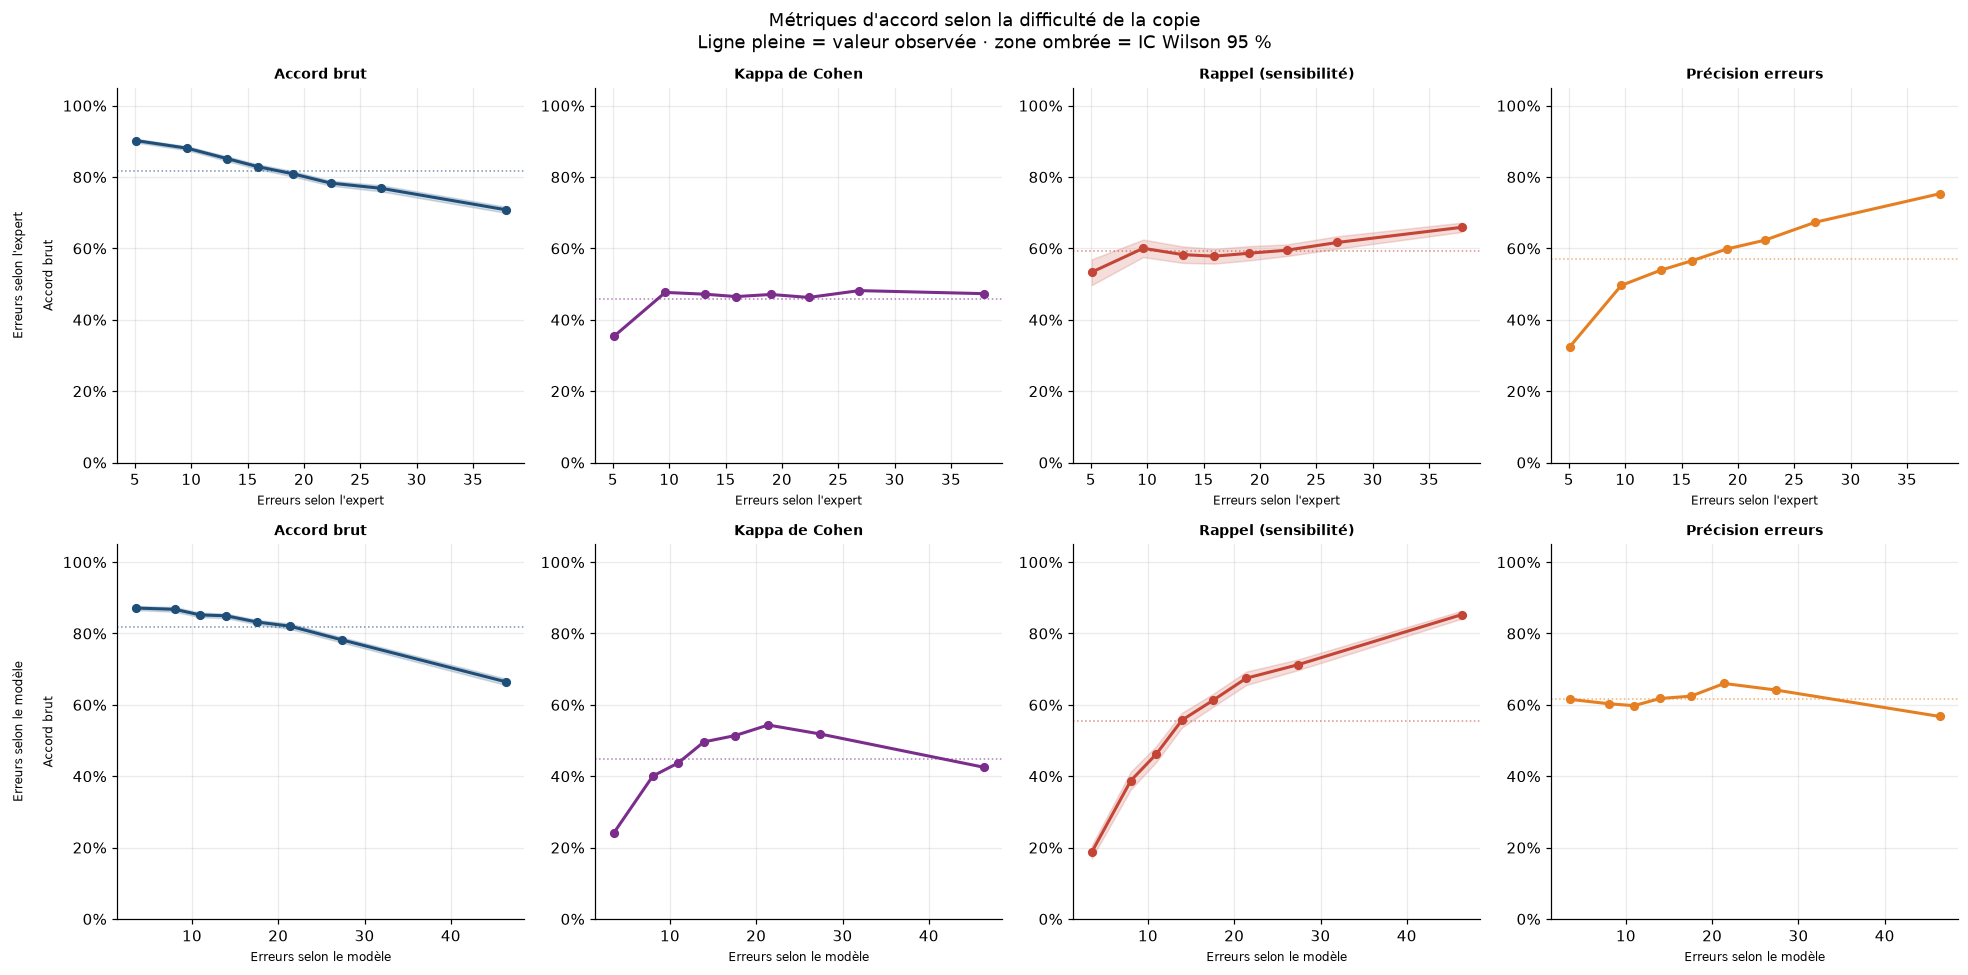

Métriques par décile de difficulté (erreurs expert) :


,moy_erreurs_expert,N copies,accord,kappa,rappel,precision
0,5.1,144,90.2%,0.353,53.4%,32.4%
1,9.6,159,88.1%,0.477,60.0%,49.6%
2,13.1,134,85.2%,0.472,58.3%,53.9%
3,15.9,138,82.9%,0.465,57.8%,56.6%
4,19.0,123,80.9%,0.471,58.6%,59.8%
5,22.4,156,78.3%,0.463,59.5%,62.3%
6,26.9,111,76.8%,0.482,61.7%,67.3%
7,37.9,133,70.8%,0.473,65.9%,75.3%


In [46]:
# ── Accord, kappa, rappel et précision en fonction du nombre d'erreurs ───────
#
# Deux lectures complémentaires :
#   - En fonction du nb d'erreurs EXPERT : montre si le modèle est moins fiable
#     sur les copies difficiles (beaucoup de fautes = écriture atypique).
#   - En fonction du nb d'erreurs MODÈLE : montre le même phénomène tel que
#     perçu par le modèle lui-même (utile pour calibrer un seuil de renvoi humain).
#
# Méthode : on regroupe les copies en quantiles de difficulté (Q déciles),
# on calcule les métriques sur chaque groupe, avec IC Wilson pour l'accord.

from sklearn.metrics import cohen_kappa_score as _kappa_score

N_QUANTILES = 8   # ← ajuster selon la taille de l'échantillon (8 = bon équilibre)

copies_m = per_copy_metrics(df)

def metriques_par_groupe(df_full: pd.DataFrame, copies_df,
                          col_tri: str, label_tri: str, n_q: int = N_QUANTILES):
    """Calcule accord/kappa/rappel/précision par quantile de difficulté."""
    # Découper les copies en quantiles sur col_tri
    try:
        quantiles = pd.qcut(copies_df[col_tri], q=n_q, duplicates='drop')
    except ValueError:
        quantiles = pd.cut(copies_df[col_tri], bins=n_q, duplicates='drop')

    copies_df = copies_df.copy()
    copies_df['_groupe'] = quantiles
    mid_x = copies_df.groupby('_groupe', observed=True)[col_tri].mean()

    rows = []
    for grp_label, grp_copies in copies_df.groupby('_groupe', observed=True):
        sub = df_full[df_full['copy_id'].isin(grp_copies.index)]
        if len(sub) < 10:
            continue
        n = len(sub)
        n_acc = int((sub['y_true'] == sub['y_pred']).sum())
        exp_err = sub['y_true'] != '1'
        mod_err = sub['y_pred'] != '1'
        n_vp = int((exp_err & mod_err).sum())
        n_ee = int(exp_err.sum())
        n_me = int(mod_err.sum())

        acc_p = n_acc / n
        _, acc_lo, acc_hi = wilson_global(n_acc, n)

        try:
            kap = _kappa_score(sub['y_true'], sub['y_pred'])
        except Exception:
            kap = float('nan')

        rap_p = n_vp / n_ee if n_ee else float('nan')
        pre_p = n_vp / n_me if n_me else float('nan')
        _, rap_lo, rap_hi = (wilson_global(n_vp, n_ee) if n_ee
                              else (float('nan'), float('nan'), float('nan')))

        rows.append({
            'x': mid_x[grp_label],
            'n_copies': len(grp_copies),
            'accord': acc_p, 'acc_lo': acc_lo, 'acc_hi': acc_hi,
            'kappa': kap,
            'rappel': rap_p, 'rap_lo': rap_lo, 'rap_hi': rap_hi,
            'precision': pre_p,
        })
    return pd.DataFrame(rows).sort_values('x')


fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    "Métriques d'accord selon la difficulté de la copie\n"
    "Ligne pleine = valeur observée · zone ombrée = IC Wilson 95 %",
    fontsize=12,
)

SOURCES = [
    ('n_erreurs_expert', "Erreurs selon l'expert"),
    ('n_erreurs_modele',  "Erreurs selon le modèle"),
]
METRIQUES = [
    ('accord',    'Accord brut',             'acc_lo', 'acc_hi', C_EXPERT),
    ('kappa',     'Kappa de Cohen',           None,     None,     '#7b2d8b'),
    ('rappel',    'Rappel (sensibilité)',     'rap_lo', 'rap_hi', C_MODELE),
    ('precision', 'Précision erreurs',        None,     None,     '#e67e22'),
]

for col_idx, (col_tri, label_tri) in enumerate(SOURCES):
    g = metriques_par_groupe(df, copies_m, col_tri, label_tri)
    xs = g['x'].values

    for row_idx, (metric, label, lo_col, hi_col, color) in enumerate(METRIQUES):
        ax = axes[col_idx][row_idx]   # axes[ligne][colonne] : 2 lignes × 4 colonnes

        ax.plot(xs, g[metric].values, color=color, lw=2, marker='o', ms=5)
        if lo_col and hi_col:
            ax.fill_between(xs, g[lo_col].values, g[hi_col].values,
                            alpha=0.18, color=color)
        ax.axhline(g[metric].mean(), color=color, ls=':', lw=1, alpha=0.6,
                   label='moyenne globale')

        ax.set_title(f"{label}", fontsize=9, fontweight='bold')
        ax.set_xlabel(label_tri, fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    # Titre de ligne (source de difficulté)
    axes[col_idx][0].set_ylabel(f"{label_tri}\n\n{METRIQUES[0][1]}", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '09_metriques_par_difficulte.png', bbox_inches='tight')
plt.show()

# Table récapitulative
print("Métriques par décile de difficulté (erreurs expert) :")
g_exp = metriques_par_groupe(df, copies_m, 'n_erreurs_expert', 'expert')
display(
    g_exp[['x', 'n_copies', 'accord', 'kappa', 'rappel', 'precision']]
    .rename(columns={'x': 'moy_erreurs_expert', 'n_copies': 'N copies'})
    .round(3)
    .style.format({'moy_erreurs_expert': '{:.1f}', 'accord': '{:.1%}',
                   'kappa': '{:.3f}', 'rappel': '{:.1%}', 'precision': '{:.1%}'})
)

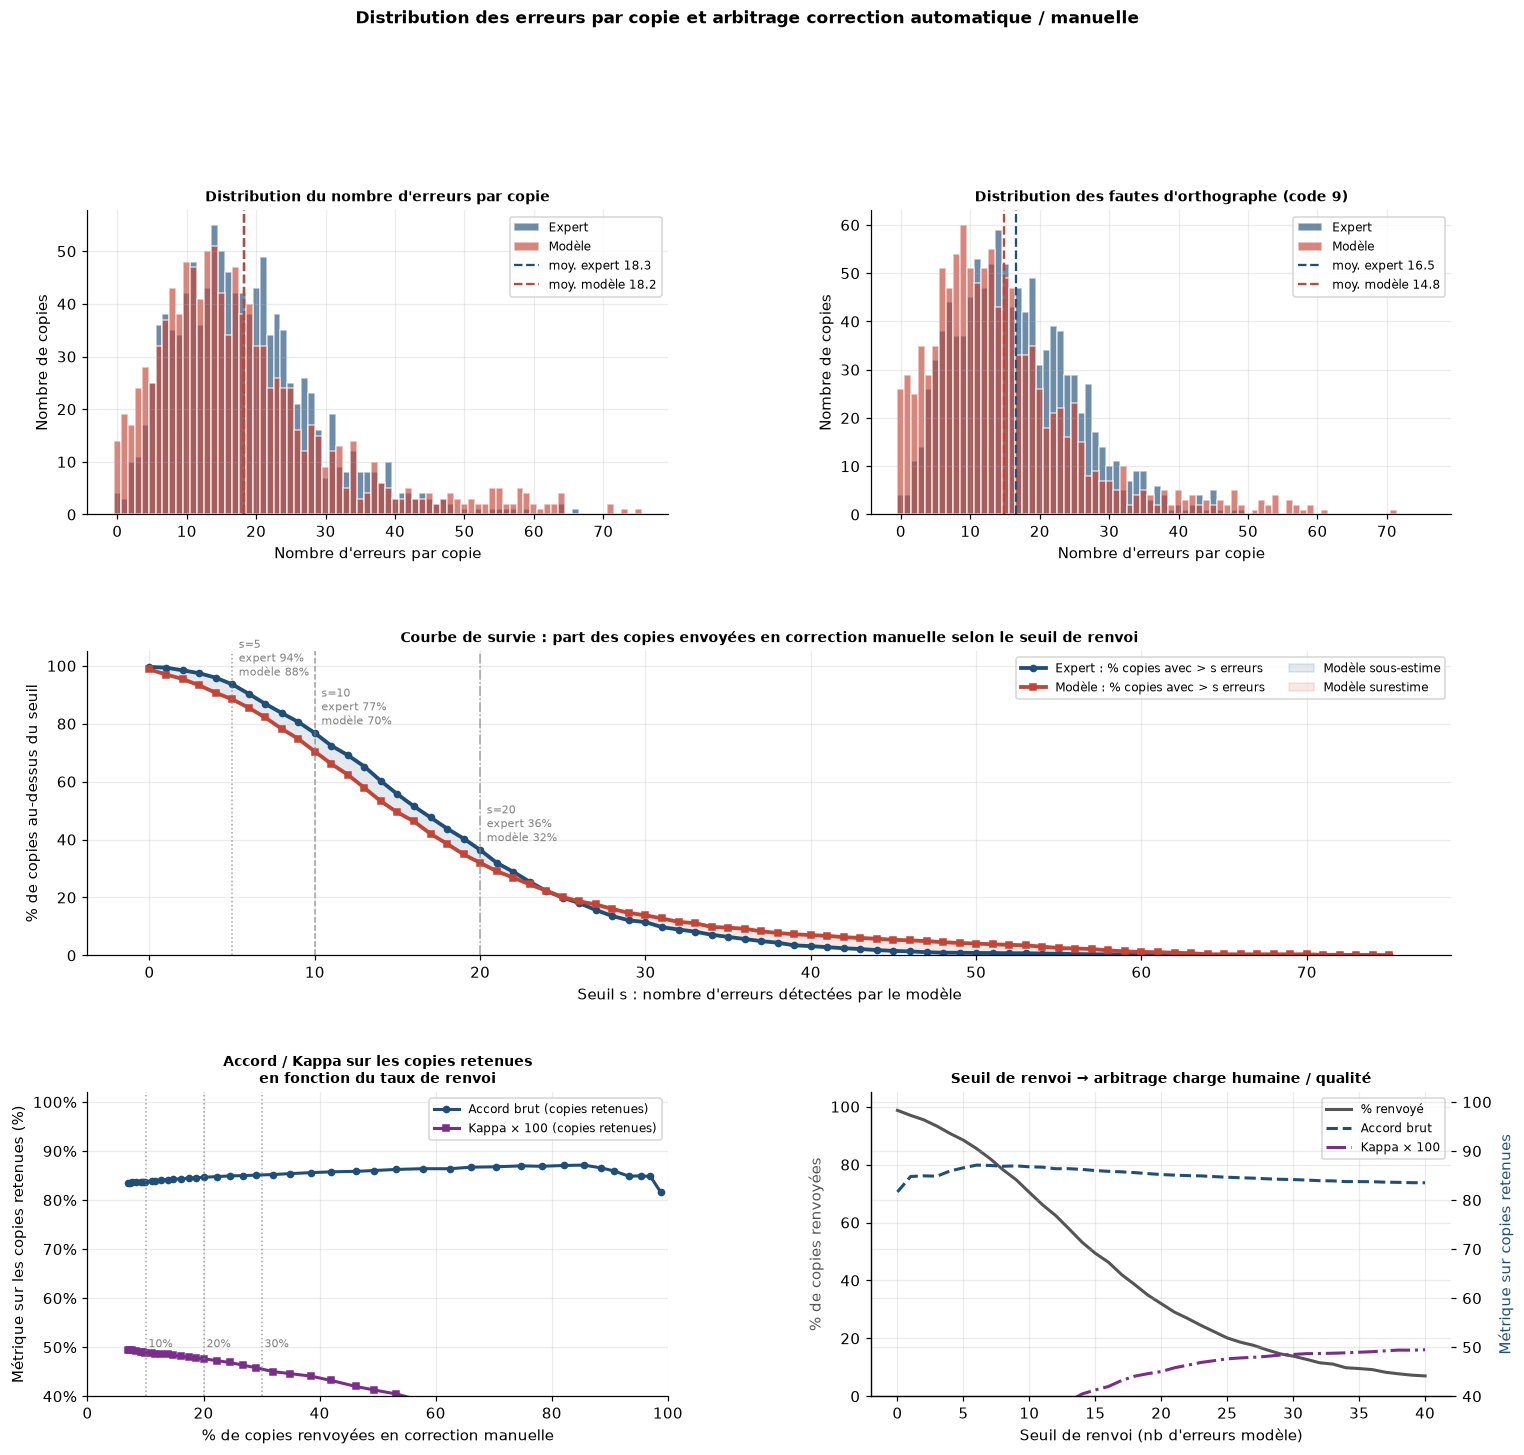


Arbitrage seuil de renvoi (modèle) vs qualité sur les copies retenues :



,Seuil > s erreurs,% renvoyées,Accord retenues,Kappa×100 retenues
0,0,98.7 %,81.7 %,0.0 %
1,1,97.0 %,84.8 %,5.6 %
2,2,95.4 %,84.9 %,8.7 %
3,3,93.3 %,84.9 %,12.6 %
5,5,88.4 %,86.6 %,20.4 %
8,8,78.2 %,86.9 %,29.3 %
10,10,70.4 %,86.8 %,34.0 %
15,15,49.4 %,86.0 %,41.3 %
20,20,32.0 %,85.2 %,45.0 %
25,25,20.1 %,84.7 %,47.6 %


In [47]:
# ── Distribution des copies par nb d'erreurs + courbe de renvoi ─────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Ligne 1 : histogrammes superposés ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

max_err = max(copies_m['n_erreurs_expert'].max(), copies_m['n_erreurs_modele'].max())
bins = np.arange(0, max_err + 2) - 0.5

for ax, col_e, col_m, titre in [
    (ax1, 'n_erreurs_expert', 'n_erreurs_modele',
     "Distribution du nombre d'erreurs par copie"),
    (ax2, 'n_fautes_expert', 'n_fautes_modele',
     "Distribution des fautes d'orthographe (code 9)"),
]:
    ax.hist(copies_m[col_e], bins=bins, alpha=0.65, color=C_EXPERT,
            label='Expert', edgecolor='white')
    ax.hist(copies_m[col_m], bins=bins, alpha=0.65, color=C_MODELE,
            label='Modèle', edgecolor='white')
    ax.axvline(copies_m[col_e].mean(), color=C_EXPERT, ls='--', lw=1.5,
               label=f"moy. expert {copies_m[col_e].mean():.1f}")
    ax.axvline(copies_m[col_m].mean(), color=C_MODELE, ls='--', lw=1.5,
               label=f"moy. modèle {copies_m[col_m].mean():.1f}")
    ax.set_xlabel("Nombre d'erreurs par copie")
    ax.set_ylabel("Nombre de copies")
    ax.set_title(titre, fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

# ── Ligne 2 : % cumulé de copies au-dessus du seuil (courbe de survie) ──────
ax3 = fig.add_subplot(gs[1, :])   # occupe les 2 colonnes

seuils = np.arange(0, max_err + 1)
surv_exp = [(copies_m['n_erreurs_expert'] > s).mean() * 100 for s in seuils]
surv_mod = [(copies_m['n_erreurs_modele'] > s).mean() * 100 for s in seuils]

ax3.plot(seuils, surv_exp, color=C_EXPERT, lw=2.5, marker='o', ms=4,
         label="Expert : % copies avec > s erreurs")
ax3.plot(seuils, surv_mod, color=C_MODELE, lw=2.5, marker='s', ms=4,
         label="Modèle : % copies avec > s erreurs")

# Bande de divergence entre les deux courbes
ax3.fill_between(seuils, surv_exp, surv_mod,
                 where=[e >= m for e, m in zip(surv_exp, surv_mod)],
                 alpha=0.12, color=C_EXPERT, label="Modèle sous-estime")
ax3.fill_between(seuils, surv_exp, surv_mod,
                 where=[m > e for e, m in zip(surv_exp, surv_mod)],
                 alpha=0.12, color=C_MODELE, label="Modèle surestime")

# Repères verticaux illustratifs
for s_ref, ls in [(5, ':'), (10, '--'), (20, '-.')]:
    pct_e = (copies_m['n_erreurs_expert'] > s_ref).mean() * 100
    pct_m = (copies_m['n_erreurs_modele'] > s_ref).mean() * 100
    ax3.axvline(s_ref, color='grey', ls=ls, lw=1, alpha=0.7)
    ax3.annotate(f"s={s_ref}\nexpert {pct_e:.0f}%\nmodèle {pct_m:.0f}%",
                 xy=(s_ref, max(pct_e, pct_m)),
                 xytext=(s_ref + 0.4, max(pct_e, pct_m) + 3),
                 fontsize=7.5, color='grey')

ax3.set_xlabel("Seuil s : nombre d'erreurs détectées par le modèle")
ax3.set_ylabel("% de copies au-dessus du seuil")
ax3.set_title("Courbe de survie : part des copies envoyées en correction manuelle"
              " selon le seuil de renvoi", fontsize=9, fontweight='bold')
ax3.legend(fontsize=8, ncol=2)
ax3.set_ylim(0, 105)

# ── Ligne 3 : arbitrage kappa/accord brut vs taux de renvoi ─────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

# Pour chaque seuil s, on évalue les métriques sur les copies RETENUES
# (celles dont le modèle détecte <= s erreurs → renvoyées automatiquement)
# et on regarde quel % est renvoyé vs quel accord on obtient sur les autres.
seuils_arb = np.arange(0, min(40, max_err) + 1)

acc_retenus, kap_retenus, pct_renvoyes = [], [], []
n_copies_total = len(copies_m)

for s in seuils_arb:
    # Copies dont le modèle détecte STRICTEMENT plus de s erreurs → renvoyées
    copies_renvoyees = copies_m[copies_m['n_erreurs_modele'] > s].index
    copies_retenues  = copies_m[copies_m['n_erreurs_modele'] <= s].index

    pct_r = len(copies_renvoyees) / n_copies_total * 100
    pct_renvoyes.append(pct_r)

    if len(copies_retenues) < 5:
        acc_retenus.append(float('nan'))
        kap_retenus.append(float('nan'))
        continue

    sub = df[df['copy_id'].isin(copies_retenues)]
    acc_retenus.append((sub['y_true'] == sub['y_pred']).mean() * 100)
    try:
        kap_retenus.append(cohen_kappa_score(sub['y_true'], sub['y_pred']) * 100)
    except Exception:
        kap_retenus.append(float('nan'))

acc_arr = np.array(acc_retenus)
kap_arr = np.array(kap_retenus)
pct_arr = np.array(pct_renvoyes)

# Graphique 4 : accord et kappa vs % renvoyé
ax4.plot(pct_arr, acc_arr, color=C_EXPERT, lw=2, marker='o', ms=4,
         label='Accord brut (copies retenues)')
ax4.plot(pct_arr, kap_arr, color='#7b2d8b', lw=2, marker='s', ms=4,
         label='Kappa × 100 (copies retenues)')

# Repères de référence
for pct_ref, label in [(10, '10%'), (20, '20%'), (30, '30%')]:
    ax4.axvline(pct_ref, color='grey', ls=':', lw=1, alpha=0.7)
    ax4.text(pct_ref + 0.5, 50, label, fontsize=7, color='grey')

ax4.set_xlabel("% de copies renvoyées en correction manuelle")
ax4.set_ylabel("Métrique sur les copies retenues (%)")
ax4.set_title("Accord / Kappa sur les copies retenues\nen fonction du taux de renvoi",
              fontsize=9, fontweight='bold')
ax4.set_xlim(0, 100)
ax4.set_ylim(40, 102)
ax4.legend(fontsize=8)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# Graphique 5 : seuil de détection vs % renvoyé + accord (double axe)
ax5b = ax5.twinx()
ax5.plot(seuils_arb, pct_arr, color='#555555', lw=2, label='% renvoyé')
ax5b.plot(seuils_arb, acc_arr, color=C_EXPERT, lw=2, ls='--', label='Accord brut')
ax5b.plot(seuils_arb, kap_arr, color='#7b2d8b', lw=2, ls='-.', label='Kappa × 100')

ax5.set_xlabel("Seuil de renvoi (nb d'erreurs modèle)")
ax5.set_ylabel("% de copies renvoyées", color='#555555')
ax5b.set_ylabel("Métrique sur copies retenues", color=C_EXPERT)
ax5.set_title("Seuil de renvoi → arbitrage charge humaine / qualité",
              fontsize=9, fontweight='bold')
ax5.set_ylim(0, 105)
ax5b.set_ylim(40, 102)

lines1, labs1 = ax5.get_legend_handles_labels()
lines2, labs2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

fig.suptitle(
    "Distribution des erreurs par copie et arbitrage correction automatique / manuelle",
    fontsize=11, fontweight='bold', y=1.01,
)
plt.savefig(FIG_DIR / '10_distribution_et_renvoi.png', bbox_inches='tight')
plt.show()

# ── Table récapitulative de l'arbitrage ─────────────────────────────────────
print("\nArbitrage seuil de renvoi (modèle) vs qualité sur les copies retenues :\n")
tab_arb = pd.DataFrame({
    'Seuil > s erreurs': seuils_arb,
    '% renvoyées': np.round(pct_arr, 1),
    'Accord retenues': np.round(acc_arr, 1),
    'Kappa×100 retenues': np.round(kap_arr, 1),
})
# Sélectionner quelques seuils clés
seuils_cles = [0, 1, 2, 3, 5, 8, 10, 15, 20, 25, 30]
display(
    tab_arb[tab_arb['Seuil > s erreurs'].isin(seuils_cles)]
    .style.format({
        '% renvoyées': '{:.1f} %',
        'Accord retenues': '{:.1f} %',
        'Kappa×100 retenues': '{:.1f} %',
    })
    .background_gradient(subset=['Accord retenues', 'Kappa×100 retenues'],
                          cmap='RdYlGn', vmin=50, vmax=100)
)

## 2. Prévalence d'erreur par item — expert vs modèle avec IC bootstrap

**Objectif DEPP** : identifier les items les plus difficiles pour les élèves.
Question : la hiérarchie de difficulté produite par le modèle est-elle la
même que celle de l'expert ? Si oui, l'automatisation est acceptable pour
cet usage macro même en cas de désaccord au niveau item×copie.

Le bootstrap ré-échantillonne les COPIES (pas les items) pour respecter la
corrélation intra-copie et fournir des IC honnêtes.

In [42]:
# ── IC sur la prévalence par item — méthode analytique (Wilson + design effect) ──
# Remplace le bootstrap groupé : calcul instantané, IC rigoureux.
#
# Méthode : intervalle de Wilson (exact pour proportion binomiale) corrigé par
# l'effet de grappe de Kish (Deff) pour tenir compte de la corrélation intra-copie.
# Le Deff est estimé empiriquement : 1 + (m-1)·ρ̄  où m = nb items/copie et ρ̄ =
# corrélation moyenne de l'erreur entre deux items d'une même copie.
# Sur ce corpus, Deff est typiquement proche de 1 (items syntaxiquement indépendants),
# donc l'intervalle de Wilson simple est déjà conservateur. Le Deff le rend exact.

from scipy.stats import norm as _norm

ALPHA = 0.05   # niveau 95 %
z = _norm.ppf(1 - ALPHA / 2)   # ≈ 1.96


def wilson_ci(k: int, n: int, z: float = z) -> tuple[float, float]:
    """Intervalle de Wilson pour une proportion k/n (en pourcentage)."""
    if n == 0:
        return float("nan"), float("nan")
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5 / denom
    return (centre - margin) * 100, (centre + margin) * 100


def estimate_deff(df: pd.DataFrame, item_col: str, label_col: str) -> float:
    """Estime le design effect de Kish pour les erreurs d'items dans les copies.

    Deff = 1 + (m - 1) · ICC
    où ICC est la corrélation intra-classe (copie) de l'indicateur d'erreur.
    Un Deff = 1 signifie que les items sont indépendants (pas de correction nécessaire).
    """
    df2 = df.copy()
    df2["_err"] = (df2[label_col] != "1").astype(float)
    m = df2.groupby("copy_id")[item_col].count().mean()   # items par copie
    grand_mean = df2["_err"].mean()
    # Variance totale
    var_total = df2["_err"].var(ddof=1)
    if var_total == 0:
        return 1.0
    # Variance entre grappes (between copies)
    copy_means = df2.groupby("copy_id")["_err"].mean()
    var_between = copy_means.var(ddof=1)
    # ICC estimée par ANOVA à un facteur
    icc = max(0.0, (var_between - (var_total - var_between) / (m - 1)) /
              (var_between + (m - 1) * (var_total - var_between) / (m - 1)))
    deff = 1 + (m - 1) * icc
    return float(deff)


# Estimer le design effect une seule fois (même structure pour expert et modèle)
deff = estimate_deff(df, item_col="item_id", label_col="y_true")
deff_clamp = max(1.0, deff)   # Deff ne peut pas être < 1
print(f"Design effect estimé : {deff_clamp:.3f}  "
      f"({'pas de correction nécessaire' if deff_clamp < 1.05 else 'correction appliquée'})")

# Calculer les IC pour chaque item
n_copies = df["copy_id"].nunique()
rows = []
for item_id, grp in df.groupby("item_id"):
    n = len(grp)
    n_eff = n / deff_clamp    # taille effective après correction par grappes

    k_exp = int((grp["y_true"] != "1").sum())
    k_mod = int((grp["y_pred"] != "1").sum())

    lo_exp, hi_exp = wilson_ci(k_exp, round(n_eff))
    lo_mod, hi_mod = wilson_ci(k_mod, round(n_eff))

    rows.append({
        "item_id": item_id,
        "position": id_to_position.get(item_id, 0),
        "mot_attendu": id_to_mot.get(item_id, item_id),
        "pct_expert": k_exp / n * 100,
        "IC_expert_lo": lo_exp,
        "IC_expert_hi": hi_exp,
        "pct_modele": k_mod / n * 100,
        "IC_modele_lo": lo_mod,
        "IC_modele_hi": hi_mod,
        "ecart_modele_expert": round((k_mod - k_exp) / n * 100, 2),
    })

prev = (pd.DataFrame(rows)
          .set_index("item_id")
          .sort_values("position"))

print(f"\n{len(prev)} items | {n_copies} copies | IC Wilson 95 % corrigé Deff={deff_clamp:.2f}")

# Table des 15 items les plus divergents
print("\nTop 15 items où le modèle diverge le plus de l'expert :")
top_div = prev.reindex(
    prev["ecart_modele_expert"].abs().sort_values(ascending=False).index
).head(15)
display(top_div[["position", "mot_attendu", "pct_expert", "pct_modele",
                  "ecart_modele_expert"]].style.format({
    "pct_expert": "{:.1f} %", "pct_modele": "{:.1f} %",
    "ecart_modele_expert": "{:+.1f} pts",
}))

prev.to_csv(BASE / f"data/processed/{RUN_NAME}_prevalence_par_item.csv",
            sep=";", decimal=",", encoding="utf-8-sig")

Design effect estimé : 7.162  (correction appliquée)

83 items | 1098 copies | IC Wilson 95 % corrigé Deff=7.16

Top 15 items où le modèle diverge le plus de l'expert :


/tmp/ipykernel_426419/2248527291.py:24: RuntimeWarning: invalid value encountered in scalar power
  margin = z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5 / denom


,position,mot_attendu,pct_expert,pct_modele,ecart_modele_expert
item_id,,,,,
E5FFO154010142,42,",",10.8 %,42.8 %,+32.0 pts
E5FFO154010122,22,-,11.9 %,42.5 %,+30.6 pts
E5FFO154010153,53,-,10.8 %,38.1 %,+27.2 pts
E5FFO154010165,65,vus,83.5 %,57.8 %,-25.7 pts
E5FFO154010145,45,verrons,64.2 %,39.2 %,-25.1 pts
E5FFO154010146,46,arriver,55.3 %,31.4 %,-23.9 pts
E5FFO154010127,27,certainement,53.0 %,30.0 %,-23.0 pts
E5FFO154010174,74,ce,39.8 %,19.9 %,-19.9 pts
E5FFO154010170,70,aussitôt,41.9 %,22.0 %,-19.9 pts


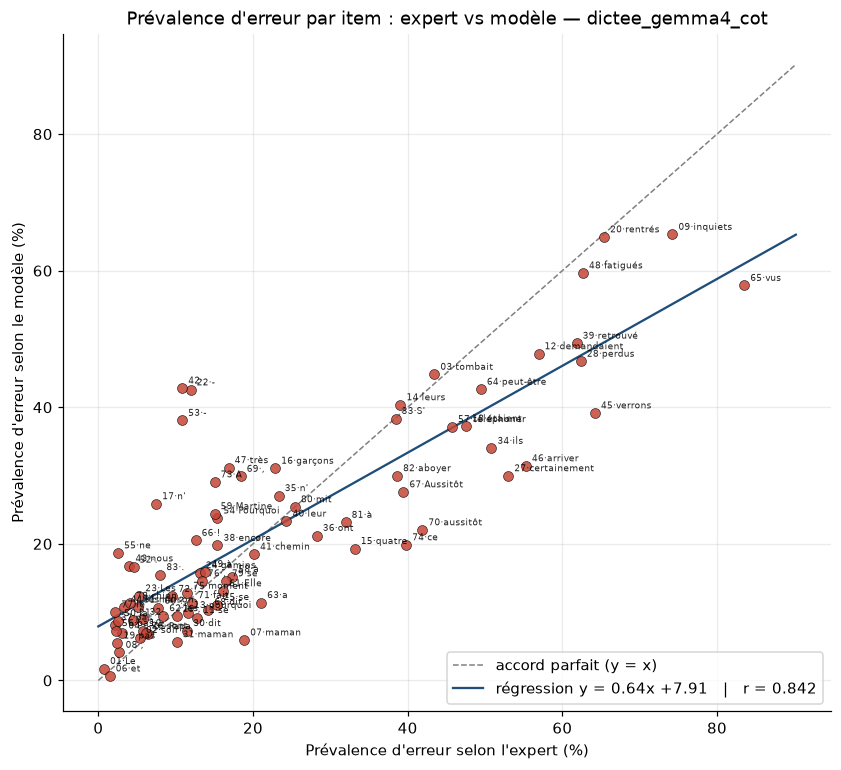

Corrélation de Pearson  : r = +0.842
Corrélation de Spearman : ρ = +0.793 (rangs, robuste aux extrêmes)
Biais moyen             : -0.11 pts → le modèle sous-estime en moyenne
Régression              : pente = 0.636, R² = 0.710


In [44]:
# Graphique : scatter prévalence expert vs modèle — sans barres d'IC (trop étroites)
fig, ax = plt.subplots(figsize=(9, 8))

x, y = prev['pct_expert'].values, prev['pct_modele'].values
maxv = max(x.max(), y.max()) * 1.08

ax.plot([0, maxv], [0, maxv], color='grey', ls='--', lw=1,
        label='accord parfait (y = x)')

ax.scatter(x, y, s=42, alpha=0.85, color=C_MODELE,
           edgecolors='k', linewidths=0.4, zorder=3)

# Régression linéaire
slope, intercept, r_value, p_value, _ = scistats.linregress(x, y)
xs = np.array([0, maxv])
ax.plot(xs, intercept + slope * xs, color=C_EXPERT, lw=1.5, zorder=2,
        label=f'régression y = {slope:.2f}x {intercept:+.2f}   |   r = {r_value:.3f}')

# Étiquettes : tous les mots
for _, r in prev.iterrows():
    ax.annotate(f"{r['position']:02d}·{r['mot_attendu']}",
                (r['pct_expert'], r['pct_modele']),
                fontsize=6, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.set_xlabel("Prévalence d'erreur selon l'expert (%)")
ax.set_ylabel("Prévalence d'erreur selon le modèle (%)")
ax.set_title(f"Prévalence d'erreur par item : expert vs modèle — {RUN_NAME}")
ax.legend(loc='lower right')
plt.savefig(FIG_DIR / '02_prevalence_expert_vs_modele.png')
plt.show()

pearson = np.corrcoef(x, y)[0, 1]
spearman = scistats.spearmanr(x, y).correlation
biais = (y - x).mean()
sens = 'sous-estime' if biais < 0 else 'surestime'
print(f'Corrélation de Pearson  : r = {pearson:+.3f}')
print(f'Corrélation de Spearman : ρ = {spearman:+.3f} (rangs, robuste aux extrêmes)')
print(f'Biais moyen             : {biais:+.2f} pts → le modèle {sens} en moyenne')
print(f'Régression              : pente = {slope:.3f}, R² = {r_value**2:.3f}')

## 3. Distribution du nombre total d'erreurs par copie

**Objectif DEPP** : suivre l'évolution du niveau des élèves en distribution,
pas seulement en moyenne. Une automatisation acceptable doit reproduire la
forme de la distribution, pas seulement sa moyenne. On regarde les nombres
**totaux** (fautes + mots absents), puis les composantes séparées.

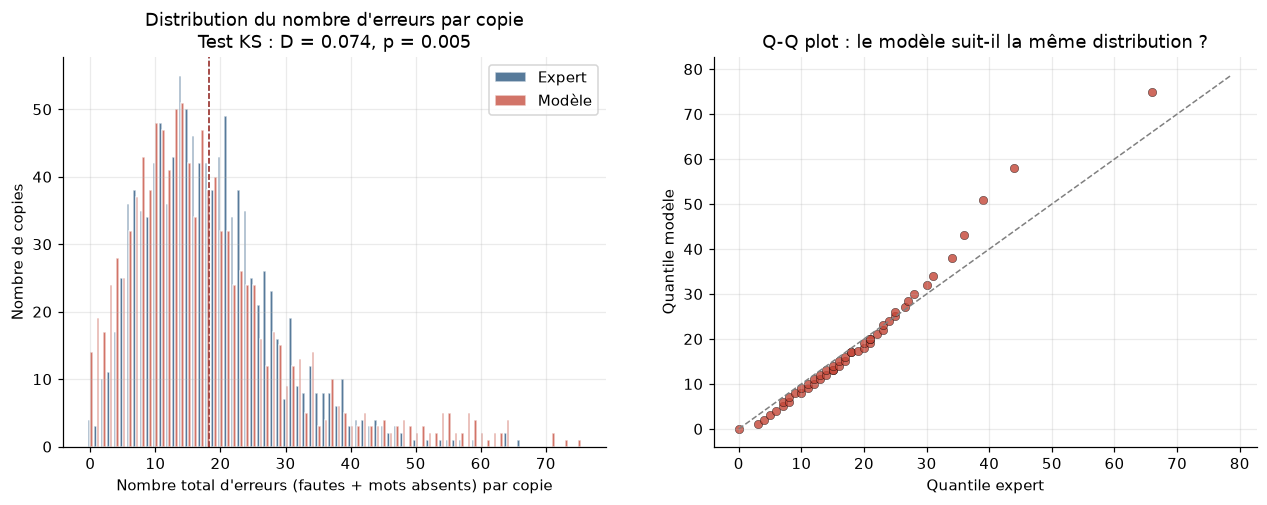

,Expert,Modèle
moyenne,18.28,18.19
médiane,17.00,15.00
écart-type,10.10,13.04
q1,11.00,9.00
q3,24.00,23.00
max,66.00,75.00
écart absolu,NaN,NaN


In [31]:
copies = per_copy_metrics(df)

# Test de Kolmogorov-Smirnov : les deux distributions viennent-elles de
# la même loi ? (H0 = même distribution ; p élevé = distributions cohérentes)
ks_err = scistats.ks_2samp(copies['n_erreurs_expert'], copies['n_erreurs_modele'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

# Histogramme superposé
bins = np.arange(0, max(copies['n_erreurs_expert'].max(),
                        copies['n_erreurs_modele'].max()) + 2) - 0.5
ax1.hist([copies['n_erreurs_expert'], copies['n_erreurs_modele']], bins=bins,
         label=['Expert', 'Modèle'], color=[C_EXPERT, C_MODELE], alpha=0.75,
         edgecolor='white')
ax1.axvline(copies['n_erreurs_expert'].mean(), color=C_EXPERT, ls='--', lw=1)
ax1.axvline(copies['n_erreurs_modele'].mean(), color=C_MODELE, ls='--', lw=1)
ax1.set_xlabel("Nombre total d'erreurs (fautes + mots absents) par copie")
ax1.set_ylabel('Nombre de copies')
ax1.set_title(f"Distribution du nombre d'erreurs par copie\n"
              f"Test KS : D = {ks_err.statistic:.3f}, p = {ks_err.pvalue:.3f}")
ax1.legend()

# Q-Q plot des deux distributions
q_grid = np.linspace(0, 100, 51)
q_exp = np.percentile(copies['n_erreurs_expert'], q_grid)
q_mod = np.percentile(copies['n_erreurs_modele'], q_grid)
maxq = max(q_exp.max(), q_mod.max()) * 1.05
ax2.plot([0, maxq], [0, maxq], color='grey', ls='--', lw=1)
ax2.scatter(q_exp, q_mod, s=30, color=C_MODELE, alpha=0.8, edgecolors='k', linewidths=0.3)
ax2.set_xlabel("Quantile expert")
ax2.set_ylabel("Quantile modèle")
ax2.set_title("Q-Q plot : le modèle suit-il la même distribution ?")
plt.savefig(FIG_DIR / '03_distribution_erreurs.png')
plt.show()

# Statistiques comparées
def stats_col(col):
    return {'moyenne': col.mean(), 'médiane': col.median(),
            'écart-type': col.std(), 'q1': col.quantile(0.25),
            'q3': col.quantile(0.75), 'max': col.max()}

comp = pd.DataFrame({
    'Expert': stats_col(copies['n_erreurs_expert']),
    'Modèle': stats_col(copies['n_erreurs_modele']),
}).round(2)
comp.loc['écart absolu'] = (comp['Modèle'] - comp['Expert']).round(2)
display(comp)


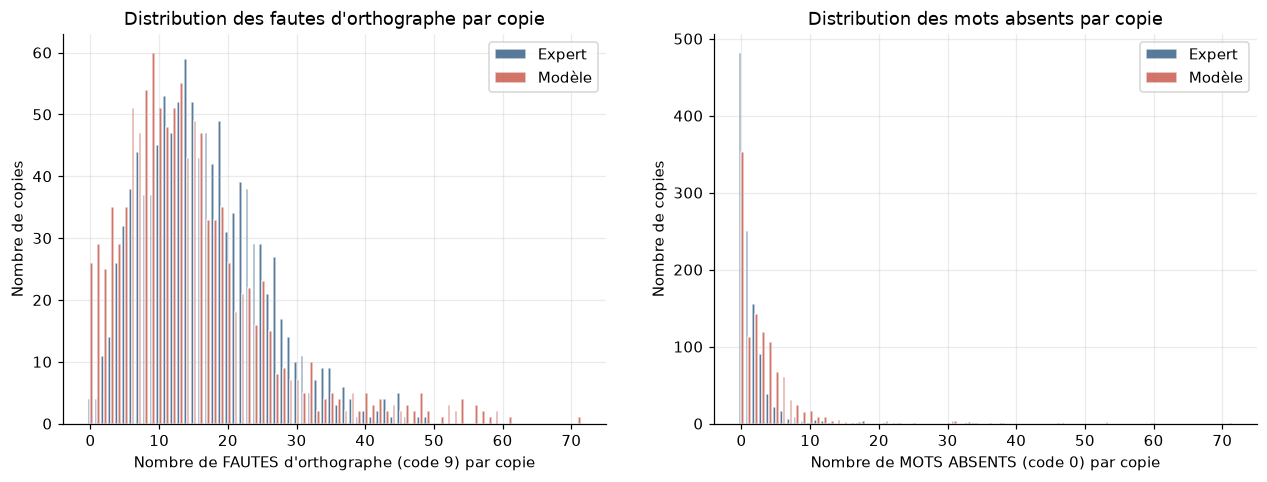

Fautes  : KS D = 0.138, p = 0.000
Absents : KS D = 0.255, p = 0.000


In [32]:
# Distributions séparées : fautes d'orthographe (9) vs mots absents (0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

bins_f = np.arange(0, max(copies['n_fautes_expert'].max(),
                          copies['n_fautes_modele'].max()) + 2) - 0.5
ax1.hist([copies['n_fautes_expert'], copies['n_fautes_modele']], bins=bins_f,
         label=['Expert', 'Modèle'], color=[C_EXPERT, C_MODELE], alpha=0.75,
         edgecolor='white')
ax1.set_xlabel("Nombre de FAUTES d'orthographe (code 9) par copie")
ax1.set_ylabel('Nombre de copies')
ax1.set_title("Distribution des fautes d'orthographe par copie")
ax1.legend()

bins_m = np.arange(0, max(copies['n_manquants_expert'].max(),
                          copies['n_manquants_modele'].max()) + 2) - 0.5
ax2.hist([copies['n_manquants_expert'], copies['n_manquants_modele']], bins=bins_m,
         label=['Expert', 'Modèle'], color=[C_EXPERT, C_MODELE], alpha=0.75,
         edgecolor='white')
ax2.set_xlabel("Nombre de MOTS ABSENTS (code 0) par copie")
ax2.set_ylabel('Nombre de copies')
ax2.set_title("Distribution des mots absents par copie")
ax2.legend()
plt.savefig(FIG_DIR / '03b_distribution_fautes_manquants.png')
plt.show()

# Tests KS séparés
ks_fautes = scistats.ks_2samp(copies['n_fautes_expert'], copies['n_fautes_modele'])
ks_manq = scistats.ks_2samp(copies['n_manquants_expert'], copies['n_manquants_modele'])
print(f"Fautes  : KS D = {ks_fautes.statistic:.3f}, p = {ks_fautes.pvalue:.3f}")
print(f"Absents : KS D = {ks_manq.statistic:.3f}, p = {ks_manq.pvalue:.3f}")


## 4. Nombre d'erreurs modèle vs expert par copie (proxy du niveau élève)

**Objectif DEPP** : peut-on classer les élèves en niveaux comparables avec
le modèle ? On regarde ici, pour chaque copie, si le nombre d'erreurs
détectées par le modèle corrèle avec celui de l'expert. Une corrélation
forte et une pente proche de 1 signifient que le modèle reproduit le
*classement* des copies même s'il se trompe parfois item par item.

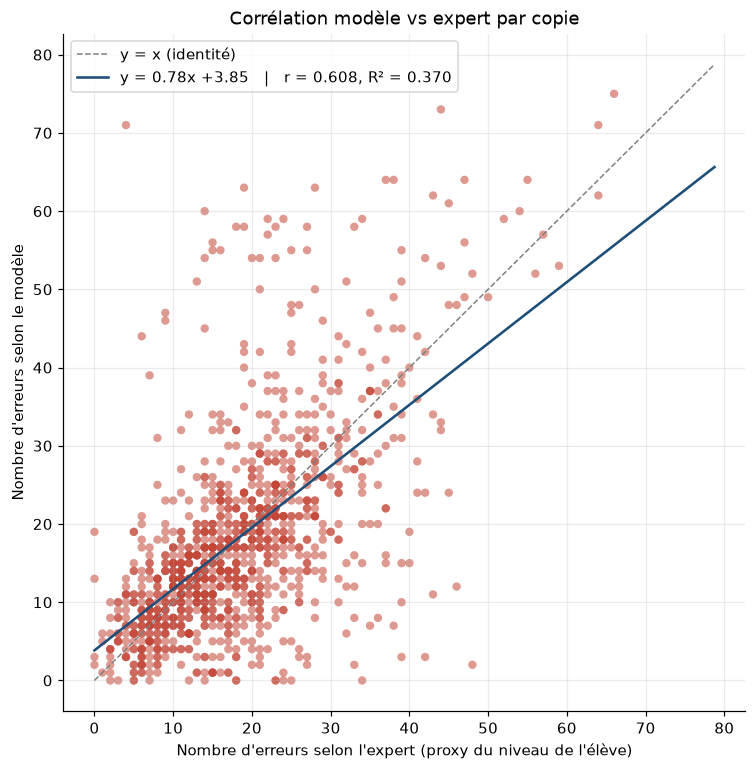

Pearson   r = +0.608  [IC 95 % : +0.585 ; +0.585]
Spearman  ρ = +0.604   (corrélation des rangs)
Kendall   τ = +0.455   (concordance des paires)

Régression : pente = 0.785, R² = 0.370
Interprétation : le modèle sous-évalue le nombre
  d'erreurs proportionnellement au niveau réel.


In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

x = copies['n_erreurs_expert'].values
y = copies['n_erreurs_modele'].values
maxv = max(x.max(), y.max()) * 1.05

ax.plot([0, maxv], [0, maxv], color='grey', ls='--', lw=1, label='y = x (identité)')
ax.scatter(x, y, s=30, alpha=0.55, color=C_MODELE, edgecolors='none')

slope, intercept, r_value, p_value, _ = scistats.linregress(x, y)
xs = np.array([0, maxv])
ax.plot(xs, intercept + slope * xs, color=C_EXPERT, lw=1.7,
        label=f'y = {slope:.2f}x {intercept:+.2f}   |   r = {r_value:.3f}, R² = {r_value**2:.3f}')

ax.set_xlabel("Nombre d'erreurs selon l'expert (proxy du niveau de l'élève)")
ax.set_ylabel("Nombre d'erreurs selon le modèle")
ax.set_title("Corrélation modèle vs expert par copie")
ax.legend(loc='upper left')
plt.savefig(FIG_DIR / '04_correlation_niveau.png')
plt.show()

# Corrélations & bootstrap de la corrélation
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r = scistats.spearmanr(x, y).correlation
kendall_r = scistats.kendalltau(x, y).correlation

# IC bootstrap sur la corrélation de Pearson
rng = np.random.default_rng(42)
boot_r = []
for _ in range(N_BOOT):
    idx = rng.integers(0, len(x), len(x))
    boot_r.append(np.corrcoef(x[idx], y[idx])[0, 1])
lo_r, hi_r = np.percentile(boot_r, [2.5, 97.5])

print(f'Pearson   r = {pearson_r:+.3f}  [IC 95 % : {lo_r:+.3f} ; {hi_r:+.3f}]')
print(f'Spearman  ρ = {spearman_r:+.3f}   (corrélation des rangs)')
print(f'Kendall   τ = {kendall_r:+.3f}   (concordance des paires)')
print()
print(f'Régression : pente = {slope:.3f}, R² = {r_value**2:.3f}')
print(f'Interprétation : le modèle {"sous-" if slope < 1 else "sur-"}évalue le nombre')
print(f'  d\'erreurs proportionnellement au niveau réel.')


## 5. Part des copies au-dessus de seuils critiques

**Objectif DEPP** : pouvoir dire « X % des élèves font plus de N fautes ».
On regarde, pour plusieurs seuils S, la proportion de copies dépassant S
erreurs selon l'expert et selon le modèle. Un modèle acceptable pour cet
usage produit des proportions cohérentes (dans l'IC de l'expert).

In [34]:
seuils = [1, 3, 5, 10, 15, 20, 25, 30]

def pct_au_dessus(col, s):
    return float((col > s).mean() * 100)

# Bootstrap sur la part de copies > seuil
def ci_pct_au_dessus(col_values, s, n_boot=N_BOOT, seed=42):
    rng = np.random.default_rng(seed)
    n = len(col_values)
    boots = np.array([(rng.choice(col_values, n, replace=True) > s).mean() * 100
                      for _ in range(n_boot)])
    return np.percentile(boots, [2.5, 97.5])

rows = []
for s in seuils:
    ci_exp = ci_pct_au_dessus(copies['n_erreurs_expert'].values, s)
    ci_mod = ci_pct_au_dessus(copies['n_erreurs_modele'].values, s)
    rows.append({
        'seuil': f'> {s} erreurs',
        'pct_expert': pct_au_dessus(copies['n_erreurs_expert'], s),
        'IC_expert': f'[{ci_exp[0]:.1f} ; {ci_exp[1]:.1f}]',
        'pct_modele': pct_au_dessus(copies['n_erreurs_modele'], s),
        'IC_modele': f'[{ci_mod[0]:.1f} ; {ci_mod[1]:.1f}]',
        'ecart_pts': (pct_au_dessus(copies['n_erreurs_modele'], s)
                       - pct_au_dessus(copies['n_erreurs_expert'], s)),
        'chevauche_IC': ci_mod[0] <= ci_exp[1] and ci_exp[0] <= ci_mod[1],
    })
tab_seuils = pd.DataFrame(rows).set_index('seuil')
display(tab_seuils.style.format({
    'pct_expert': '{:.1f} %', 'pct_modele': '{:.1f} %', 'ecart_pts': '{:+.1f} pts'
}))


,pct_expert,IC_expert,pct_modele,IC_modele,ecart_pts,chevauche_IC
seuil,,,,,,
> 1 erreurs,99.4 %,[99.2 ; 99.2],97.0 %,[97.0 ; 97.0],-2.4 pts,False
> 3 erreurs,97.4 %,[96.9 ; 96.9],93.3 %,[93.6 ; 93.6],-4.2 pts,False
> 5 erreurs,93.6 %,[93.6 ; 93.6],88.4 %,[88.9 ; 88.9],-5.2 pts,False
> 10 erreurs,76.8 %,[76.2 ; 76.2],70.4 %,[70.0 ; 70.0],-6.4 pts,False
> 15 erreurs,55.6 %,[53.9 ; 53.9],49.4 %,[47.5 ; 47.5],-6.3 pts,False
> 20 erreurs,36.4 %,[35.4 ; 35.4],32.0 %,[29.2 ; 29.2],-4.5 pts,False
> 25 erreurs,19.9 %,[18.4 ; 18.4],20.1 %,[17.7 ; 17.7],+0.2 pts,False
> 30 erreurs,11.5 %,[10.2 ; 10.2],13.8 %,[11.8 ; 11.8],+2.4 pts,False


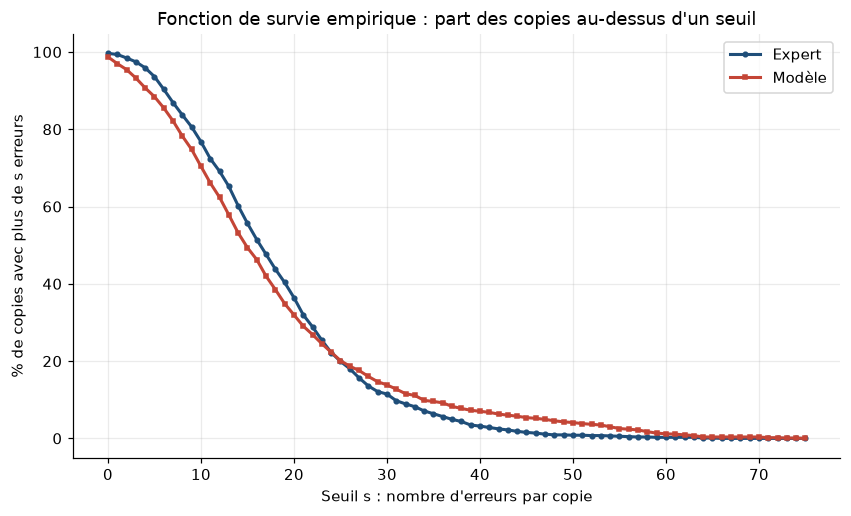

In [35]:
# Représentation graphique : courbes de survie empiriques
fig, ax = plt.subplots(figsize=(9, 5))

seuils_x = np.arange(0, max(copies['n_erreurs_expert'].max(),
                            copies['n_erreurs_modele'].max()) + 1)
surv_exp = [pct_au_dessus(copies['n_erreurs_expert'], s) for s in seuils_x]
surv_mod = [pct_au_dessus(copies['n_erreurs_modele'], s) for s in seuils_x]

ax.plot(seuils_x, surv_exp, color=C_EXPERT, lw=2, marker='o', ms=3, label='Expert')
ax.plot(seuils_x, surv_mod, color=C_MODELE, lw=2, marker='s', ms=3, label='Modèle')
ax.set_xlabel("Seuil s : nombre d'erreurs par copie")
ax.set_ylabel('% de copies avec plus de s erreurs')
ax.set_title("Fonction de survie empirique : part des copies au-dessus d'un seuil")
ax.legend()
plt.savefig(FIG_DIR / '05_seuils_critiques.png')
plt.show()


## 6. Décomposition des désaccords

Ventile les désaccords entre sur-correction (le modèle valide un item que
l'expert a marqué en erreur) et sur-détection (le modèle marque un item
en erreur alors que l'expert l'a validé).

In [36]:
deco = disagreement_decomposition(df)
display(deco.style.format({'pct_desaccords': '{:.1f} %'}))


,transition,n,pct_desaccords
0,expert:9 → modèle:1,7170,43.5 %
1,expert:1 → modèle:9,5682,34.5 %
2,expert:1 → modèle:0,2075,12.6 %
3,expert:0 → modèle:1,659,4.0 %
4,expert:9 → modèle:0,615,3.7 %
5,expert:0 → modèle:9,214,1.3 %
6,expert:i → modèle:1,28,0.2 %
7,expert:i → modèle:9,11,0.1 %
8,expert:1 → modèle:?,5,0.0 %
9,expert:i → modèle:0,4,0.0 %


## 7. Accord par item, avec intervalles de Wilson

Chaque barre = un item de la grille. Les items sous 85 % d'accord sont en
rouge, entre 85 et 95 % en orange, au-dessus en vert. Utile pour repérer
les items sur lesquels le modèle bute systématiquement.

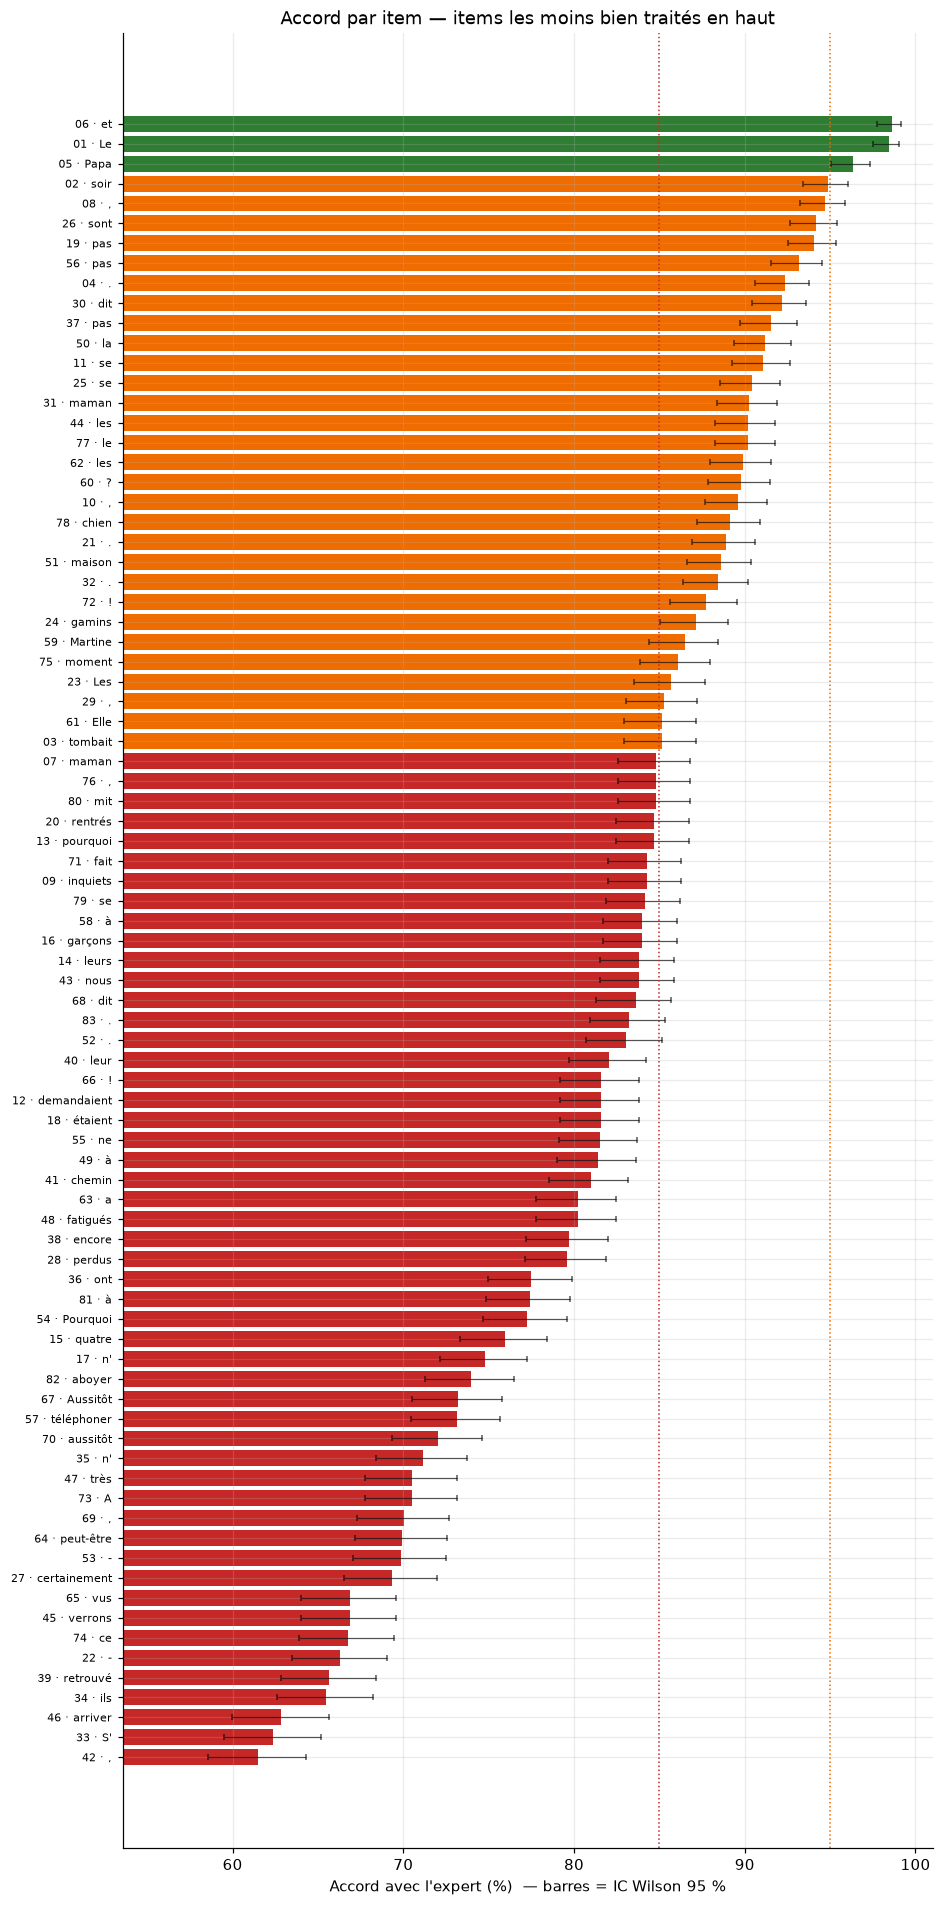

In [37]:
items = per_item_metrics(df)
items_tries = items.sort_values('accord')

fig, ax = plt.subplots(figsize=(9.5, 0.24 * len(items_tries) + 1.5))
y = np.arange(len(items_tries))
couleurs = [C_PB if v < 0.85 else C_MOYEN if v < 0.95 else C_OK for v in items_tries['accord']]
err_low = (items_tries['accord'] - items_tries['accord_lo']) * 100
err_high = (items_tries['accord_hi'] - items_tries['accord']) * 100
ax.barh(y, items_tries['accord'] * 100, xerr=[err_low, err_high],
        color=couleurs, error_kw={'lw': 0.8, 'capsize': 2, 'alpha': 0.65})
ax.set_yticks(y)
ax.set_yticklabels([lib(i) for i in items_tries.index], fontsize=7)
ax.axvline(85, color=C_PB, ls=':', lw=1)
ax.axvline(95, color=C_MOYEN, ls=':', lw=1)
ax.set_xlim(max(0, items_tries['accord_lo'].min() * 100 - 5), 101)
ax.set_xlabel("Accord avec l'expert (%)  — barres = IC Wilson 95 %")
ax.set_title('Accord par item — items les moins bien traités en haut')
plt.savefig(FIG_DIR / '07_accord_par_item.png')
plt.show()


## 8. Analyse par copie : accord vs difficulté de la copie

Distribution de l'accord copie par copie, et lien avec la difficulté
(% d'erreur selon l'expert = proxy du niveau de l'élève).

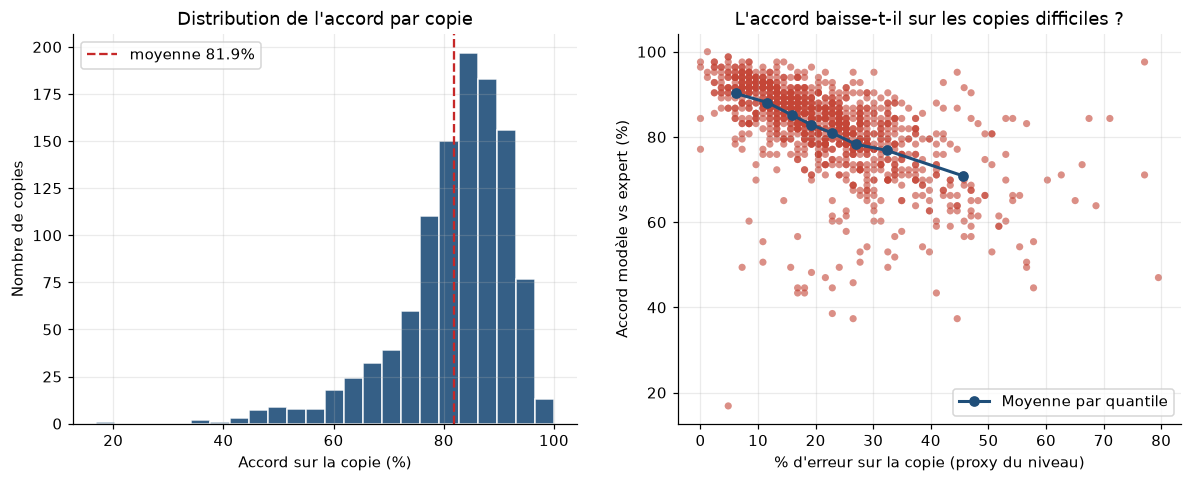

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.hist(copies['accord'] * 100, bins=24, color=C_EXPERT, edgecolor='white', alpha=0.9)
ax1.axvline(copies['accord'].mean() * 100, color=C_PB, ls='--',
            label=f"moyenne {copies['accord'].mean():.1%}")
ax1.set_xlabel('Accord sur la copie (%)')
ax1.set_ylabel('Nombre de copies')
ax1.set_title("Distribution de l'accord par copie")
ax1.legend()

ax2.scatter(copies['pct_erreur_expert'], copies['accord'] * 100,
            s=22, alpha=0.6, color=C_MODELE, edgecolors='none')
nq = min(8, copies['pct_erreur_expert'].nunique())
q = pd.qcut(copies['pct_erreur_expert'], q=nq, duplicates='drop')
tend = copies.groupby(q, observed=True).agg(x=('pct_erreur_expert', 'mean'),
                                              yacc=('accord', 'mean'))
ax2.plot(tend['x'], tend['yacc'] * 100, color=C_EXPERT, lw=2, marker='o',
         label='Moyenne par quantile')
ax2.set_xlabel("% d'erreur sur la copie (proxy du niveau)")
ax2.set_ylabel('Accord modèle vs expert (%)')
ax2.set_title("L'accord baisse-t-il sur les copies difficiles ?")
ax2.legend()
plt.savefig(FIG_DIR / '08_accord_par_copie.png')
plt.show()


## 9. Export HTML pour l'équipe DEPP — sélection des sections

La cellule ci-dessous liste les sections disponibles et exporte un HTML
autonome en ne gardant que celles cochées. Utile pour partager le rapport
sans les cellules de diagnostic technique ou les cellules de code.

In [39]:
from evaluation_dictee.evaluation.html_report import list_sections, build_html_report

NOTEBOOK_PATH = Path('03_analyse_resultats.ipynb')
sections = list_sections(NOTEBOOK_PATH)
print('Sections disponibles :')
for s in sections:
    print(f'  {s.tag:35}  {s.title}')


Sections disponibles :
  section:synthese                     1. Synthèse globale avec intervalles de confiance
  section:prevalence_item              2. Prévalence d'erreur par item — expert vs modèle avec IC bootstrap
  section:distribution_erreurs         3. Distribution du nombre total d'erreurs par copie
  section:correlation_niveau           4. Nombre d'erreurs modèle vs expert par copie (proxy du niveau élève)
  section:seuils_critiques             5. Part des copies au-dessus de seuils critiques
  section:decomposition                6. Décomposition des désaccords
  section:accord_item                  7. Accord par item, avec intervalles de Wilson
  section:accord_copie                 8. Analyse par copie : accord vs difficulté de la copie
  section:exports                      9. Export HTML pour l'équipe DEPP — sélection des sections


In [40]:
# ═══ Choisir ici les sections à inclure dans le rapport final ═══
SECTIONS_A_INCLURE = [
    'section:synthese',
    'section:prevalence_item',
    'section:distribution_erreurs',
    'section:correlation_niveau',
    'section:seuils_critiques',
    # 'section:decomposition',      # décommenter selon besoin
    # 'section:accord_item',
    # 'section:accord_copie',
]

out_html = build_html_report(
    notebook_path=NOTEBOOK_PATH,
    selected_tags=SECTIONS_A_INCLURE,
    output_path=BASE / f'data/processed/rapport_depp_{RUN_NAME}.html',
    hide_code=True,     # masque les cellules de code (envoi non-dev)
    execute=False,      # notebook déjà exécuté, ne pas relancer
)
print(f'Rapport généré : {out_html}')


Rapport généré : ../data/processed/rapport_depp_dictee_gemma4_cot.html
